# 🧠 What is PyTorch?

PyTorch is an open-source deep learning framework developed by Meta AI, known for its dynamic computation graph,
ease of use, and integration with Python. It supports GPU acceleration and is widely used for computer vision,
NLP, and more.

# 📦 Main PyTorch Modules:

    - torch: Base tensor library (similar to NumPy)
    - torch.nn: Neural network building blocks (layers, losses)
    - torch.optim: Optimization algorithms
    - torch.utils.data: Data loading and batching
    - torchvision: Popular datasets and pre-trained models

Step 1: Install required libraries (already available in Colab usually)

In [1]:
!pip install torch torchvision matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.8 MB/s eta 0:00:00


Step 2: Import necessary libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

Step 3: Set device (GPU if available)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Step 4: Define transformations for data preprocessing

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),                     # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))       # Normalize images to [-1, 1]
])

Step 5: Load CIFAR-10 dataset (10 classes like cat, dog, car, etc.)

---

### 📚 **What is the CIFAR-10 Dataset?**

The **CIFAR-10** (Canadian Institute For Advanced Research) dataset is a widely-used benchmark dataset in machine learning and computer vision tasks, especially for training and evaluating image classification models.

---

### 📦 **Key Characteristics:**

| Feature               | Description                                                       |
|-----------------------|-------------------------------------------------------------------|
| 🖼️ **Total Images**   | 60,000 color images                                               |
| 🧪 **Training Set**   | 50,000 images                                                     |
| ✅ **Test Set**       | 10,000 images                                                     |
| 📏 **Image Size**     | 32x32 pixels (RGB – 3 channels)                                   |
| 🔟 **Classes**        | 10 mutually exclusive categories                                  |
| 📂 **Format**         | Dataset is provided in Python and binary format via torchvision  |
| 🔄 **Shuffling**      | Can be shuffled easily for batch training using DataLoader        |

---

### 🏷️ **Class Labels in CIFAR-10:**

| Label Index | Class Name  | Example Objects                    |
|-------------|-------------|------------------------------------|
| 0           | airplane     | jet, passenger plane               |
| 1           | automobile   | car, pickup truck, sedan           |
| 2           | bird         | sparrow, eagle                     |
| 3           | cat          | housecat, kitten                   |
| 4           | deer         | fawn, elk                          |
| 5           | dog          | puppy, retriever                   |
| 6           | frog         | green frog, toad                   |
| 7           | horse        | pony, racing horse                 |
| 8           | ship         | cargo ship, boat                   |
| 9           | truck        | pickup, trailer                    |

---

### 🎯 **Why is CIFAR-10 Important for Learning?**

- ✅ **Beginner-friendly**: Ideal for training small Convolutional Neural Networks (CNNs).
- 🧪 **Standardized Benchmark**: Used to compare performance across models.
- 📉 **Manageable Size**: Fits in memory and trains quickly on CPU/GPU.
- 📚 **Real-World Images**: Despite small resolution, captures variety and complexity.

---

### 🧠 **Use Cases of CIFAR-10 in Deep Learning Education:**

- Teaching **CNN architectures**
- Understanding **overfitting vs. generalization**
- Visualizing **filters, activations, and feature maps**
- Testing **data augmentation** and **transfer learning**

---

In [5]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 75.5MB/s]


Step 6: Visualize a few images from the training set

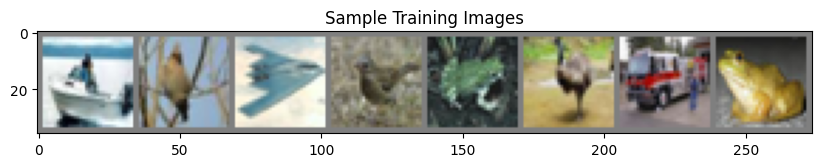

In [6]:
classes = train_dataset.classes

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10,2))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title("Sample Training Images")
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))

Step 7: Define a simple CNN using torch.nn

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Input: 3x32x32 → Output: 32x32x32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # Output: 32x16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Output: 64x16x16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # Output: 64x8x8

            nn.Flatten(),                                # Output: 64*8*8 = 4096
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 10)                           # 10 output classes
        )

    def forward(self, x):
        return self.network(x)

model = SimpleCNN().to(device)

Step 8: Define Loss function and Optimizer

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Step 9: Train the model

In [10]:
epochs = 100
train_loss_list = []

for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_loss_list.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

print("Finished Training ✅")

Epoch 1/100, Loss: 1.2920
Epoch 2/100, Loss: 0.8939
Epoch 3/100, Loss: 0.7168
Epoch 4/100, Loss: 0.5590
Epoch 5/100, Loss: 0.4111
Epoch 6/100, Loss: 0.2809
Epoch 7/100, Loss: 0.1734
Epoch 8/100, Loss: 0.1116
Epoch 9/100, Loss: 0.0850
Epoch 10/100, Loss: 0.0713
Epoch 11/100, Loss: 0.0598
Epoch 12/100, Loss: 0.0564
Epoch 13/100, Loss: 0.0534
Epoch 14/100, Loss: 0.0484
Epoch 15/100, Loss: 0.0475
Epoch 16/100, Loss: 0.0485
Epoch 17/100, Loss: 0.0433
Epoch 18/100, Loss: 0.0349
Epoch 19/100, Loss: 0.0401
Epoch 20/100, Loss: 0.0373
Epoch 21/100, Loss: 0.0405
Epoch 22/100, Loss: 0.0419
Epoch 23/100, Loss: 0.0365
Epoch 24/100, Loss: 0.0318
Epoch 25/100, Loss: 0.0320
Epoch 26/100, Loss: 0.0356
Epoch 27/100, Loss: 0.0306
Epoch 28/100, Loss: 0.0329
Epoch 29/100, Loss: 0.0298
Epoch 30/100, Loss: 0.0367
Epoch 31/100, Loss: 0.0243
Epoch 32/100, Loss: 0.0290
Epoch 33/100, Loss: 0.0336
Epoch 34/100, Loss: 0.0215
Epoch 35/100, Loss: 0.0316
Epoch 36/100, Loss: 0.0213
Epoch 37/100, Loss: 0.0302
Epoch 38/1

Step 10: Visualize Training Loss

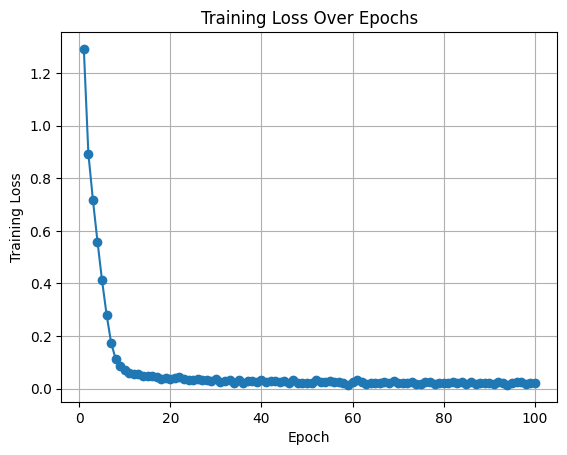

In [11]:
plt.figure()
plt.plot(range(1, epochs+1), train_loss_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

Step 11: Evaluate the model on test data

In [12]:
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 70.57%


Step 12: Show a few test predictions

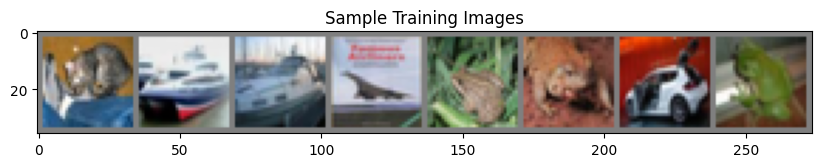

Ground Truth:  cat | ship | ship | airplane | frog | frog | automobile | frog
Predicted:     cat | ship | ship | airplane | cat | frog | automobile | cat


In [13]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Show 8 predictions
imshow(torchvision.utils.make_grid(images.cpu()[:8]))
print("Ground Truth: ", ' | '.join(classes[label] for label in labels[:8]))
print("Predicted:    ", ' | '.join(classes[p] for p in predicted[:8]))

# Extension: Real-Time Training Loss Plot for 10 Epochs

Dynamic Training with Real-time Loss Plotting

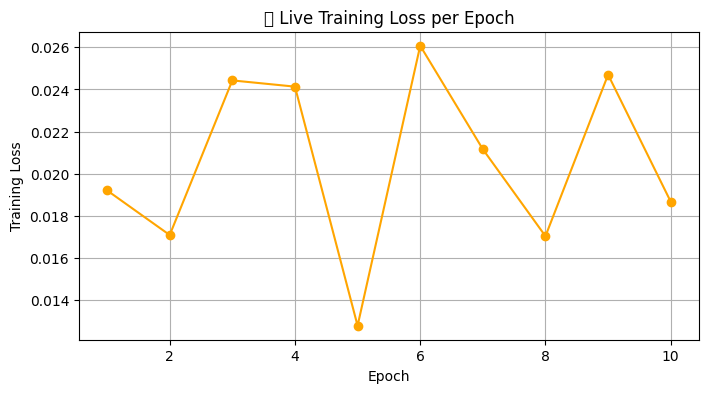

Epoch 10/10, Loss: 0.0187
✅ Training with Live Plotting Completed


In [14]:
from IPython.display import clear_output

epochs = 10
train_loss_list = []

plt.ion()  # Turn on interactive mode

for epoch in range(epochs):
    running_loss = 0.0
    model.train()

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_loss_list.append(avg_loss)

    # ✅ Real-time dynamic graph
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epoch + 2), train_loss_list, marker='o', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Live Training Loss per Epoch")
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

plt.ioff()  # Turn off interactive mode
print("✅ Training with Live Plotting Completed")


Extension Highlights:

    The extension shows live plots after each epoch with updated loss values.

    Very useful for helping us understand model convergence visually.

#📘 Summary:

This Colab code demonstrates data loading, model building, training, evaluation, and visualization using PyTorch modules.

    All major components like torch.nn, torch.optim, torch.utils.data, and torchvision are covered.

Suitable for beginners to understand end-to-end deep learning workflow.